---

### **Launch the Streamlit App: Run** `streamlit run streamlit_app.py` to start the **Streamlit** interface.

### **streamlit_app.py**
```Python
from crewai import Crew, LLM
from trip_agents import TripAgents, StreamToExpander
from trip_tasks import TripTasks
import streamlit as st
import datetime
import sys
from langchain_openai import OpenAI


st.set_page_config(page_icon="✈️", layout="wide")


def icon(emoji: str):
    """Shows an emoji as a Notion-style page icon."""
    st.write(
        f'<span style="font-size: 78px; line-height: 1">{emoji}</span>',
        unsafe_allow_html=True,
    )


class TripCrew:

    def __init__(self, origin, cities, date_range, interests):
        self.cities = cities
        self.origin = origin
        self.interests = interests
        # Convert date_range to string format for better handling
        self.date_range = f"{date_range[0].strftime('%Y-%m-%d')} to {date_range[1].strftime('%Y-%m-%d')}"
        self.output_placeholder = st.empty()
        self.llm = LLM(model="gemini/gemini-2.0-flash")
        # self.llm = OpenAI(
        #     temperature=0.7,
        #     model_name="gpt-4",
        # )

    def run(self):
        try:
            agents = TripAgents(llm=self.llm)
            tasks = TripTasks()

            city_selector_agent = agents.city_selection_agent()
            local_expert_agent = agents.local_expert()
            travel_concierge_agent = agents.travel_concierge()

            identify_task = tasks.identify_task(
                city_selector_agent,
                self.origin,
                self.cities,
                self.interests,
                self.date_range
            )

            gather_task = tasks.gather_task(
                local_expert_agent,
                self.origin,
                self.interests,
                self.date_range
            )

            plan_task = tasks.plan_task(
                travel_concierge_agent,
                self.origin,
                self.interests,
                self.date_range
            )

            crew = Crew(
                agents=[
                    city_selector_agent, local_expert_agent, travel_concierge_agent
                ],
                tasks=[identify_task, gather_task, plan_task],
                verbose=True
            )

            result = crew.kickoff()
            self.output_placeholder.markdown(result)
            return result
        except Exception as e:
            st.error(f"An error occurred: {str(e)}")
            return None


if __name__ == "__main__":
    icon("🏖️ VacAIgent")

    st.subheader("Let AI agents plan your next vacation!",
                 divider="rainbow", anchor=False)

    import datetime

    today = datetime.datetime.now().date()
    next_year = today.year + 1
    jan_16_next_year = datetime.date(next_year, 1, 10)

    with st.sidebar:
        st.header("👇 Enter your trip details")
        with st.form("my_form"):
            location = st.text_input(
                "Where are you currently located?", placeholder="San Mateo, CA")
            cities = st.text_input(
                "City and country are you interested in vacationing at?", placeholder="Bali, Indonesia")
            date_range = st.date_input(
                "Date range you are interested in traveling?",
                min_value=today,
                value=(today, jan_16_next_year + datetime.timedelta(days=6)),
                format="MM/DD/YYYY",
            )
            interests = st.text_area("High level interests and hobbies or extra details about your trip?",
                                     placeholder="2 adults who love swimming, dancing, hiking, and eating")

            submitted = st.form_submit_button("Submit")

        st.divider()

        # Credits to joaomdmoura/CrewAI for the code: https://github.com/joaomdmoura/crewAI
        st.sidebar.markdown(
        """
        Credits to [**@joaomdmoura**](https://twitter.com/joaomdmoura)
        for creating **crewAI** 🚀
        """,
            unsafe_allow_html=True
        )

        st.sidebar.info("Click the logo to visit GitHub repo", icon="👇")
        st.sidebar.markdown(
            """
        <a href="https://github.com/joaomdmoura/crewAI" target="_blank">
            <img src="https://raw.githubusercontent.com/joaomdmoura/crewAI/main/docs/crewai_logo.png" alt="CrewAI Logo" style="width:100px;"/>
        </a>
        """,
            unsafe_allow_html=True
        )


if submitted:
    with st.status("🤖 **Agents at work...**", state="running", expanded=True) as status:
        with st.container(height=500, border=False):
            sys.stdout = StreamToExpander(st)
            trip_crew = TripCrew(location, cities, date_range, interests)
            result = trip_crew.run()
        status.update(label="✅ Trip Plan Ready!",
                      state="complete", expanded=False)

    st.subheader("Here is your Trip Plan", anchor=False, divider="rainbow")
    st.markdown(result)
```
---

### **Output**
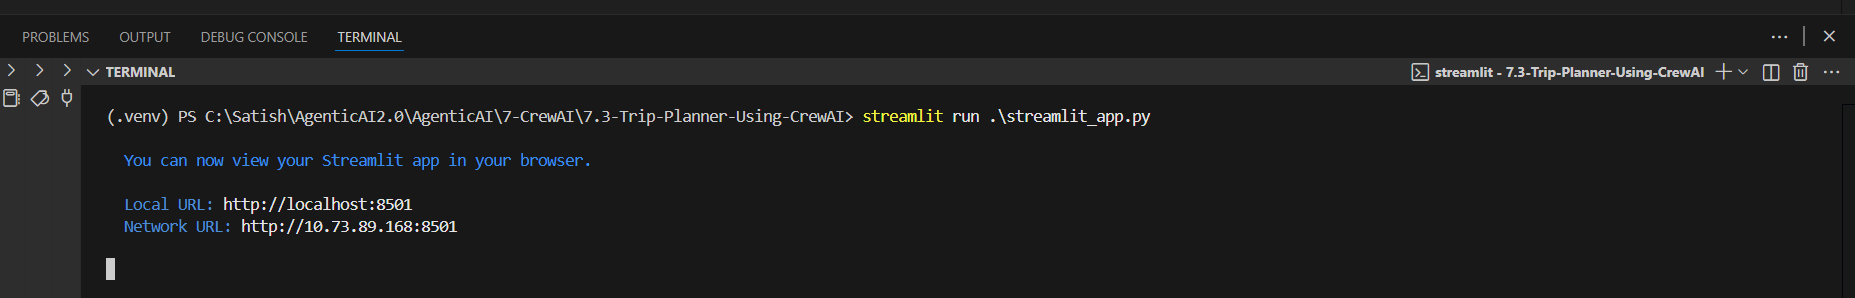 <br> 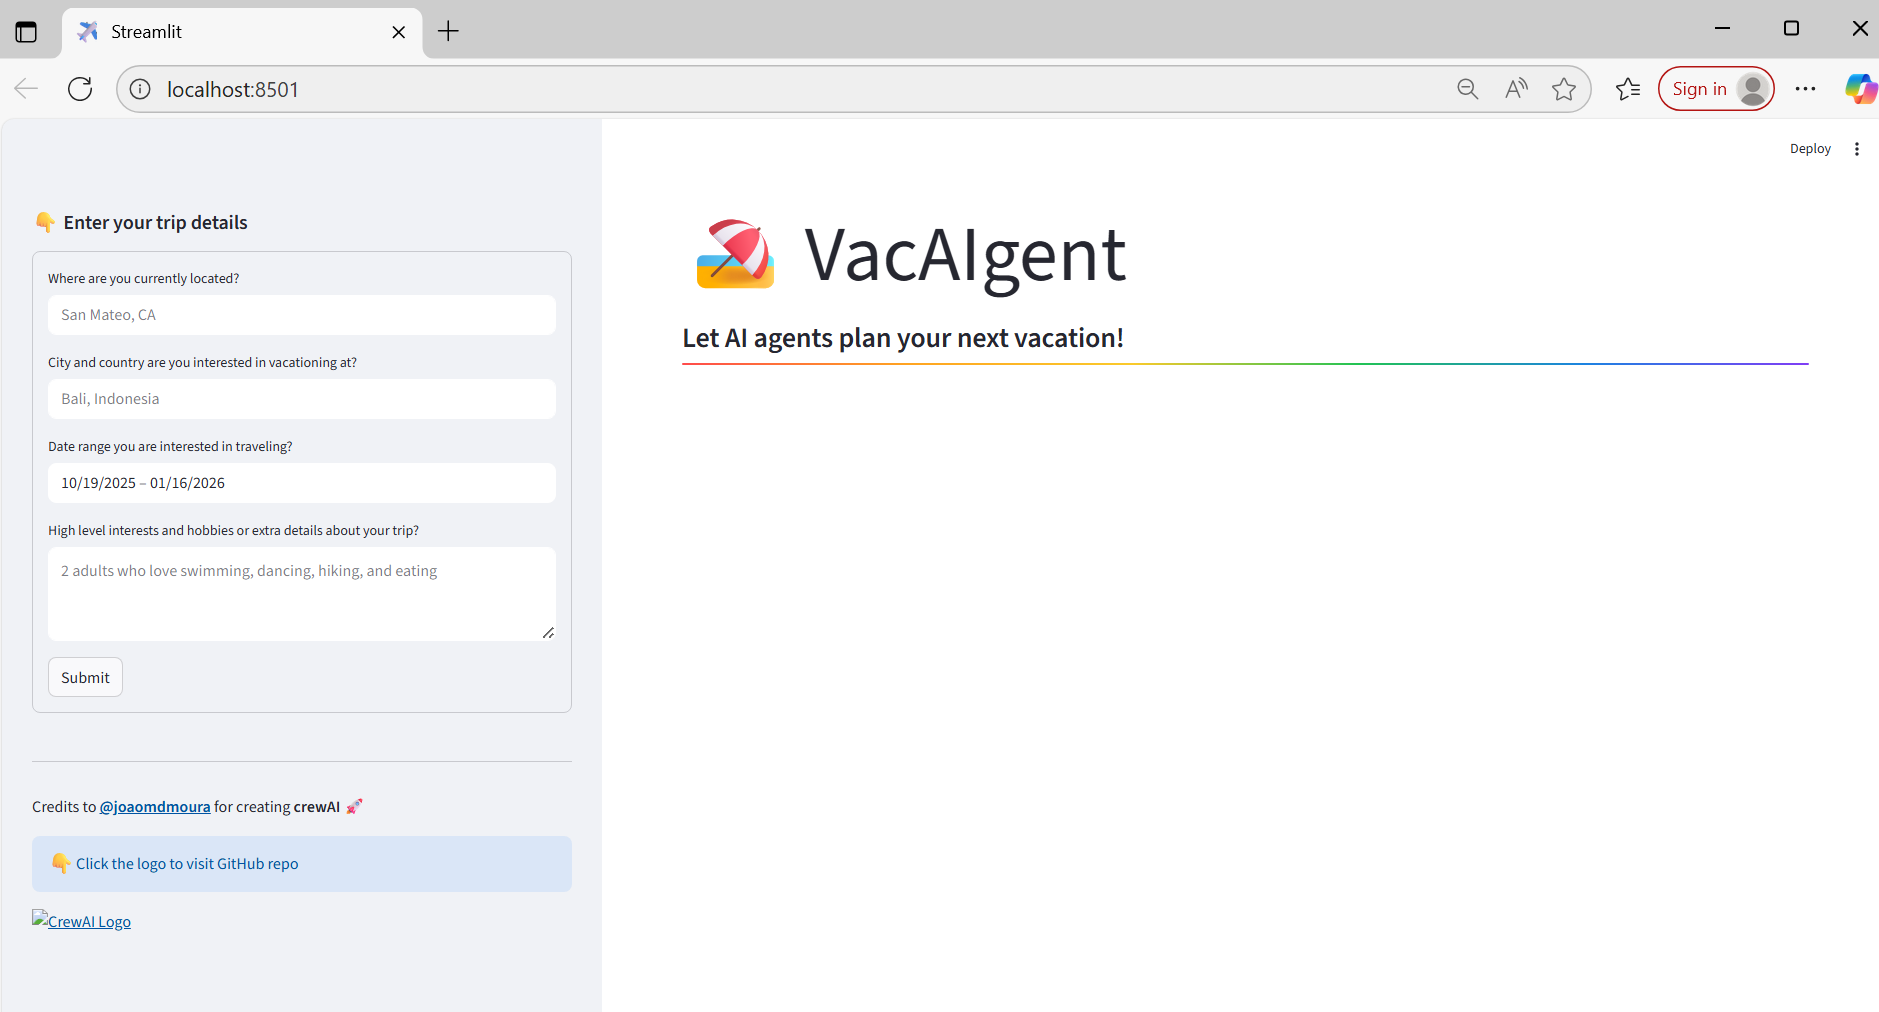 <br>
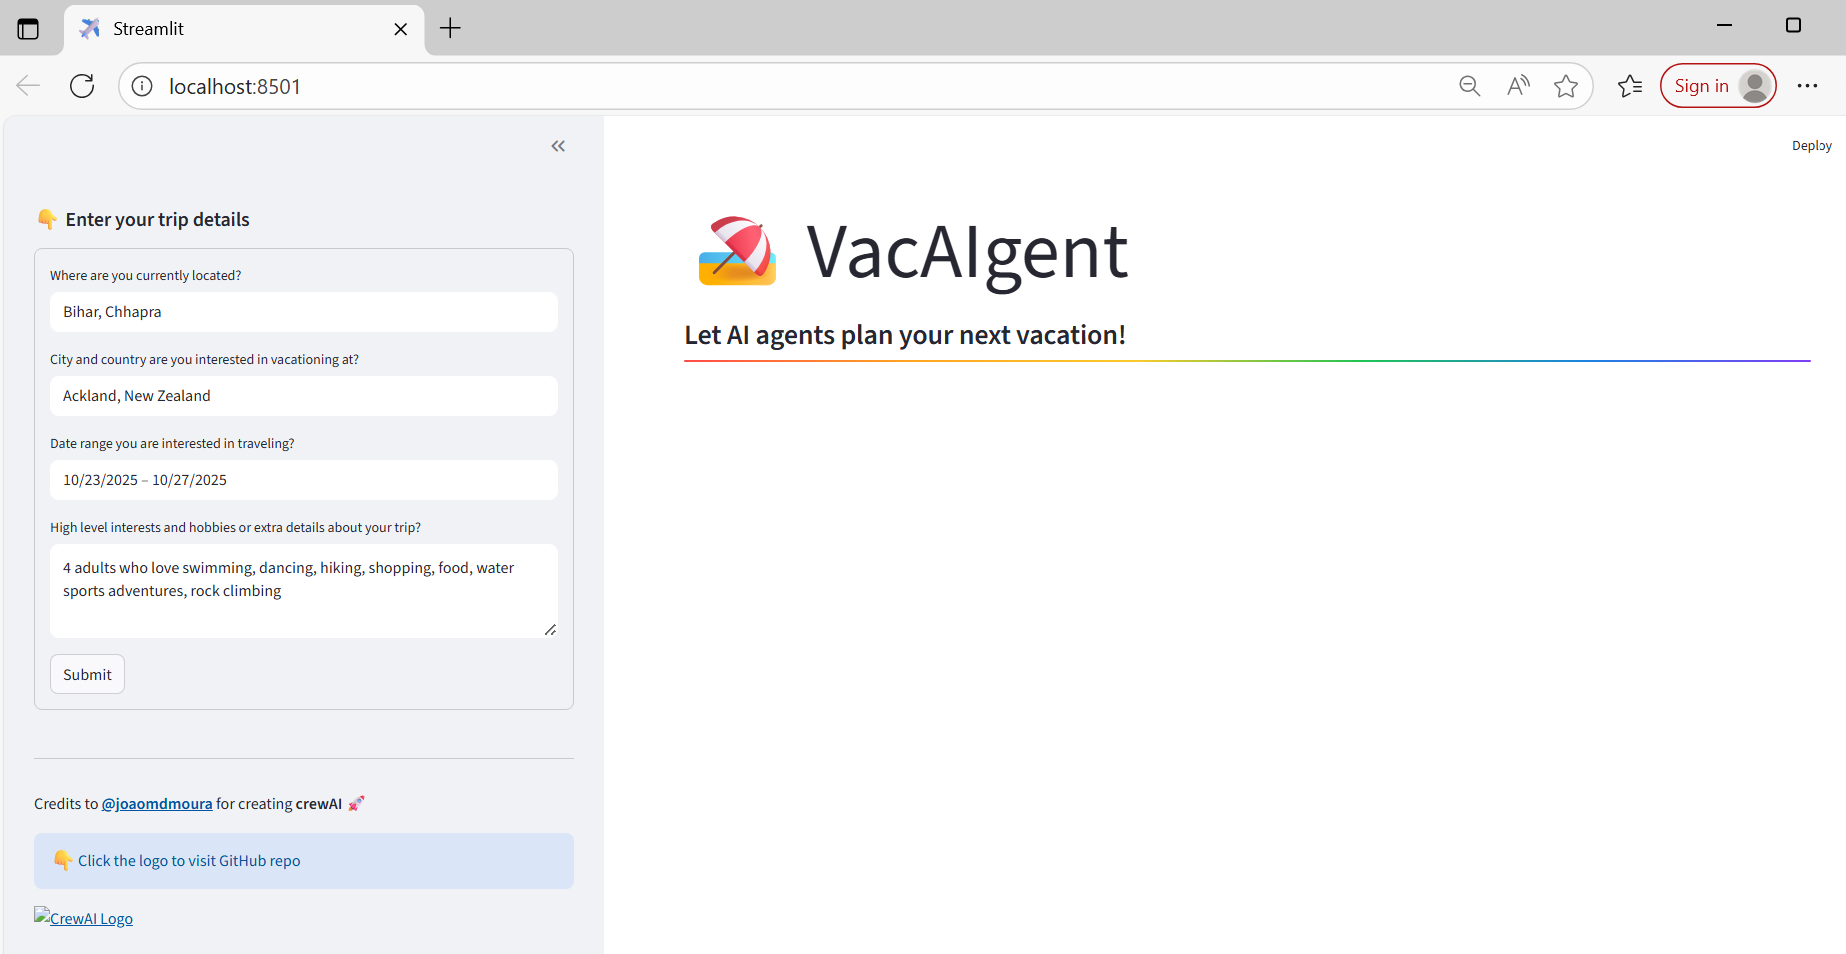 <br> 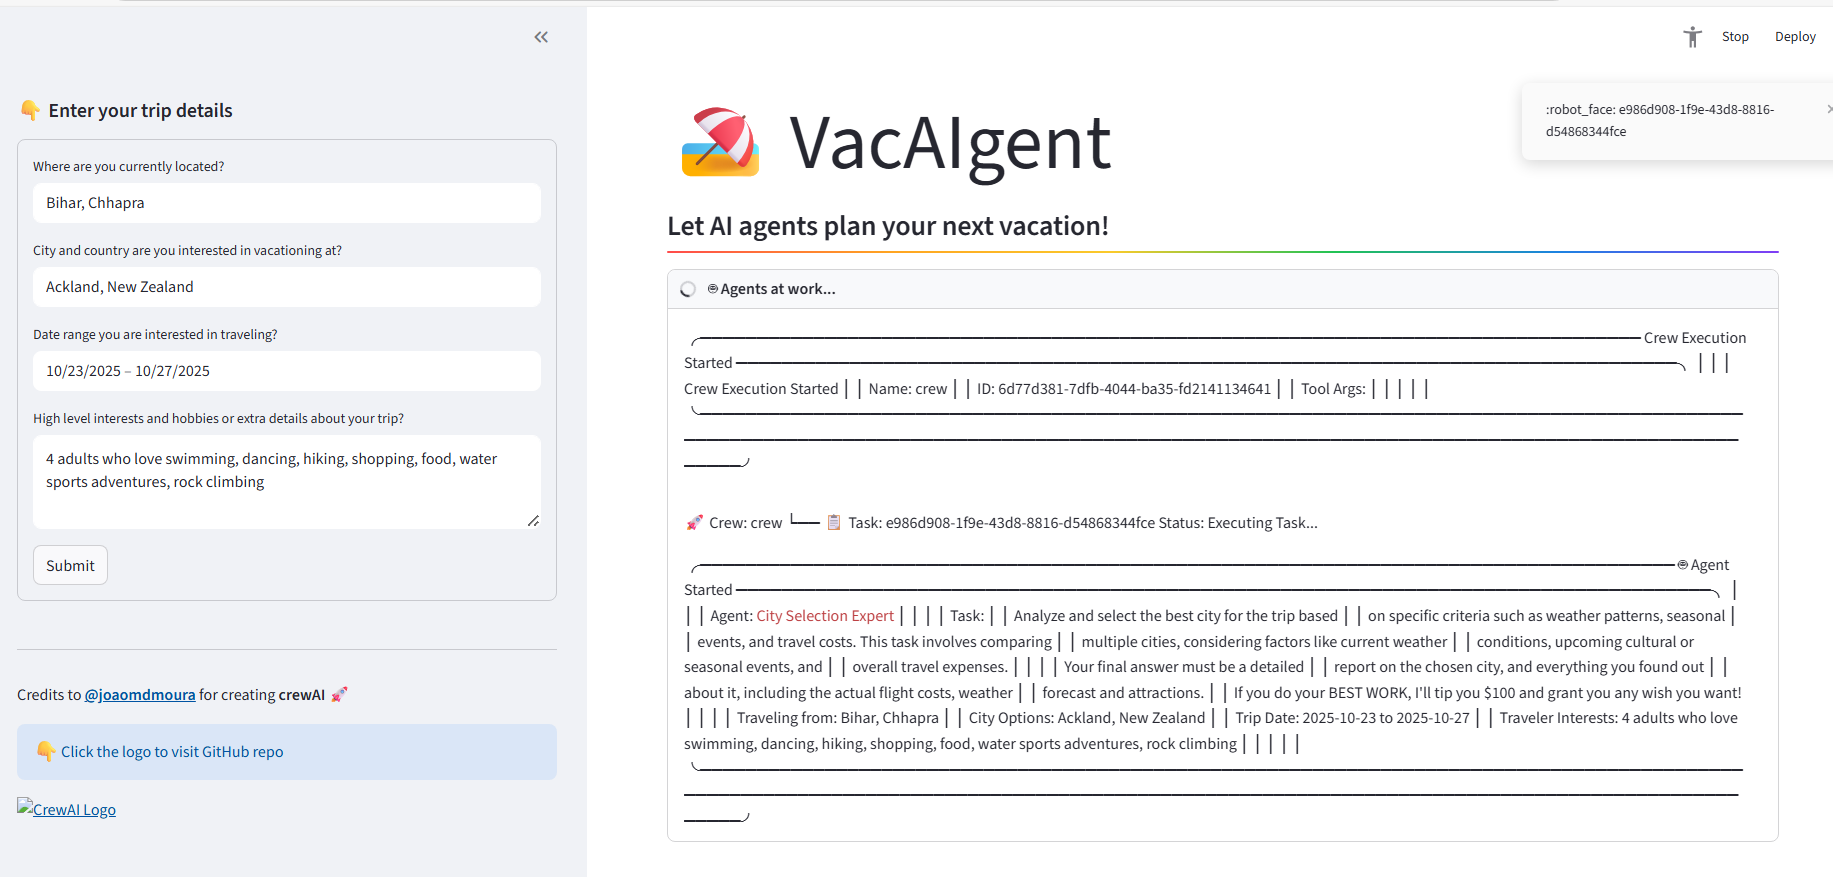 <br>
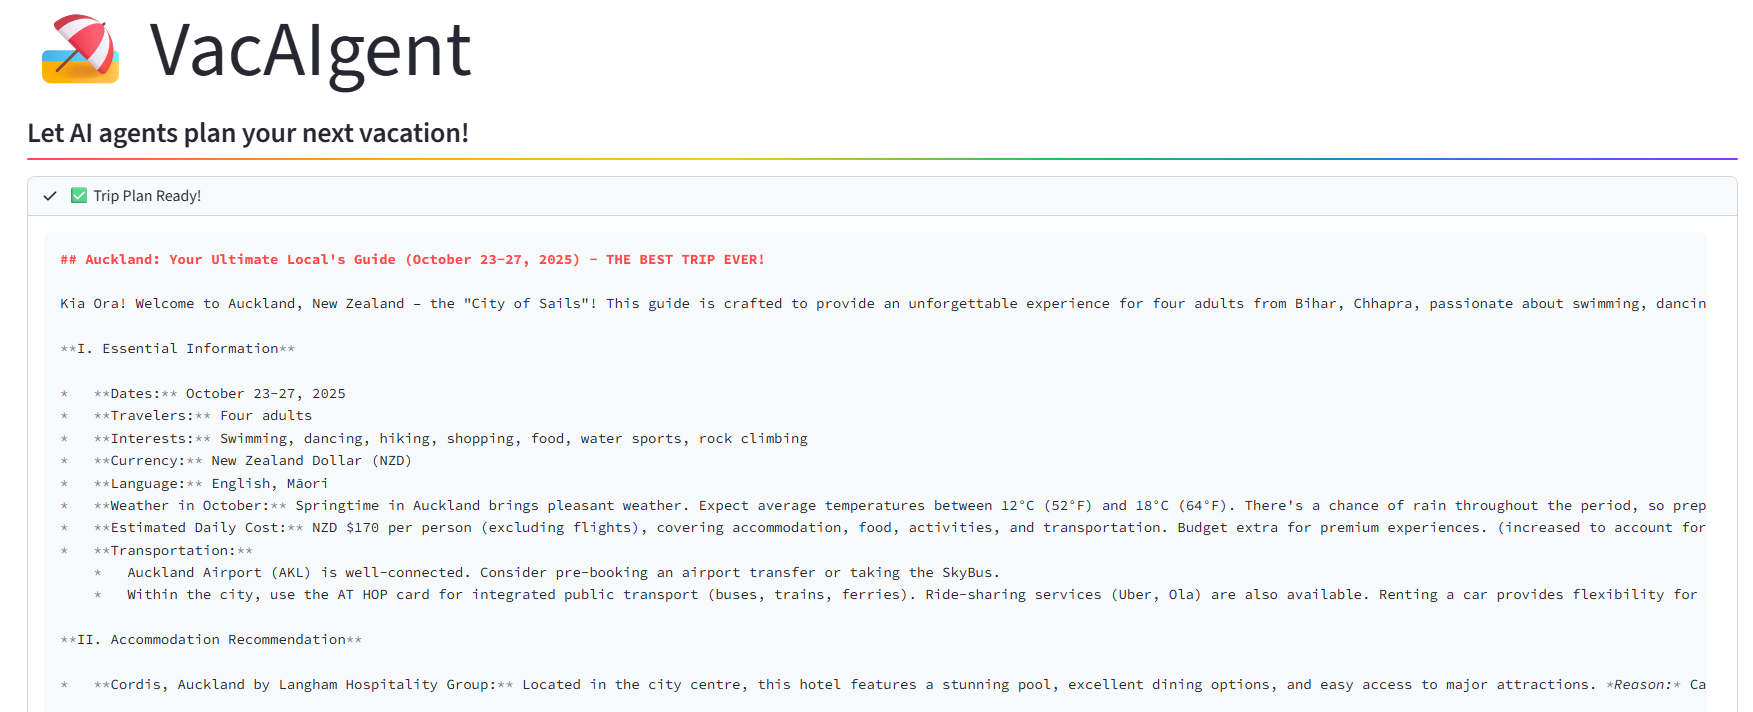 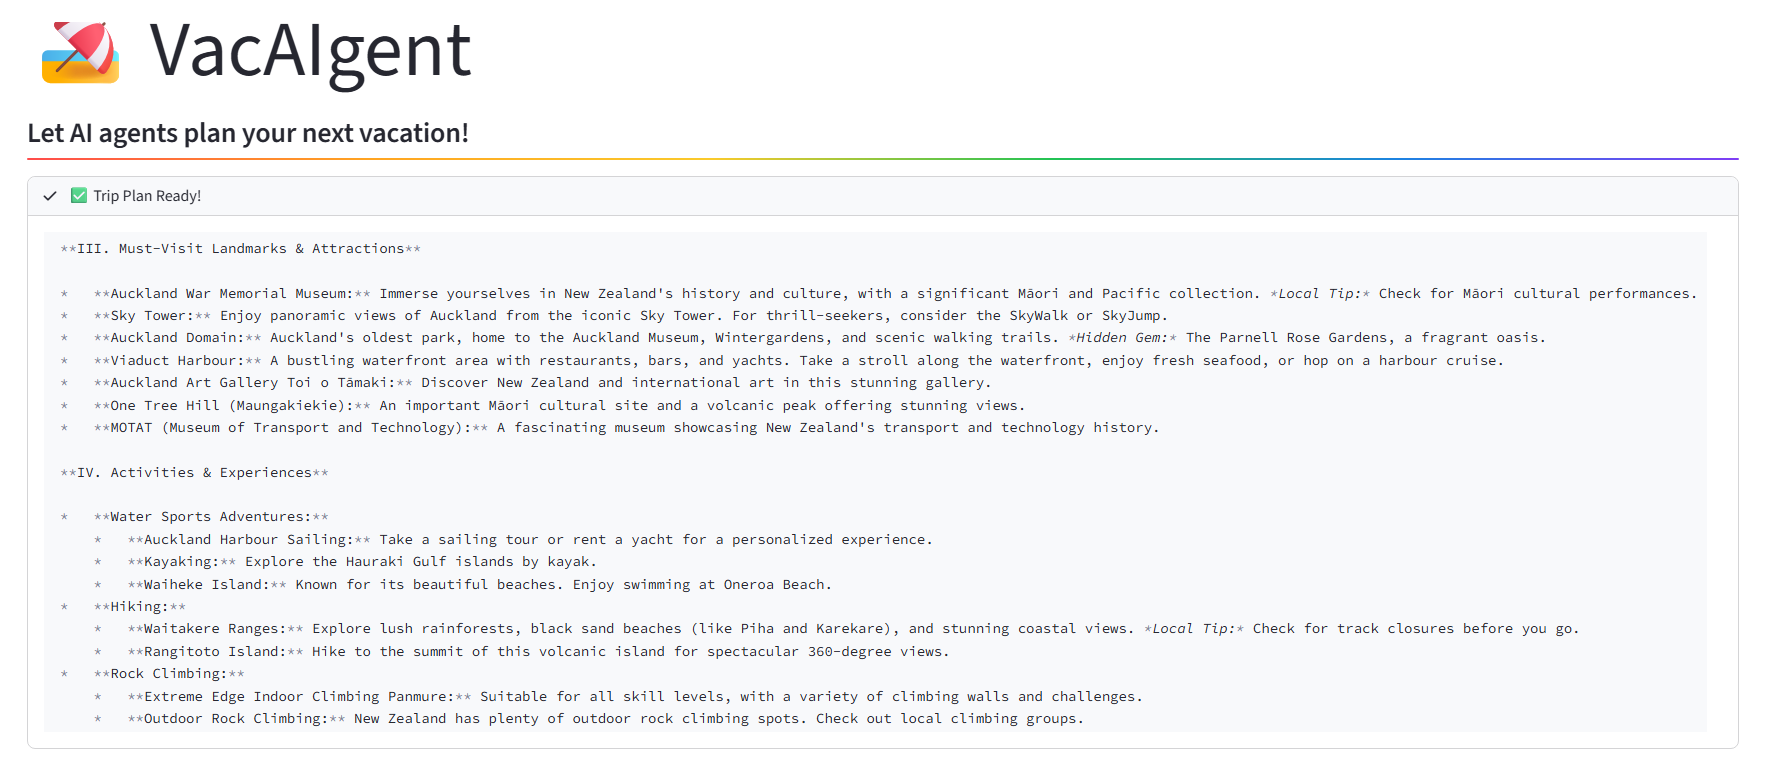 <br> 
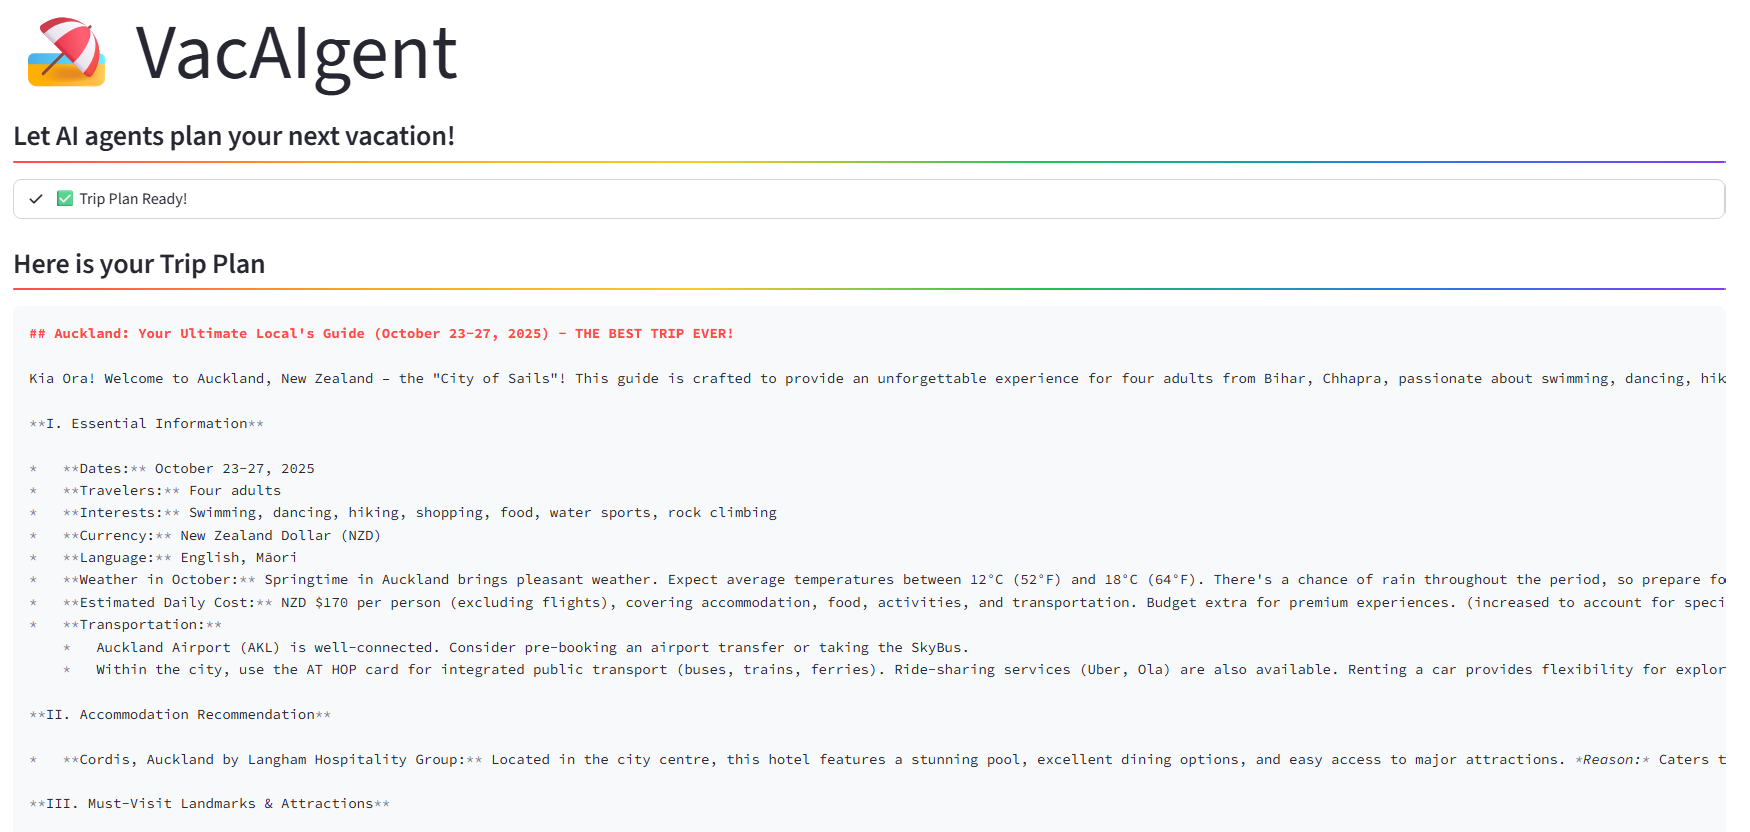 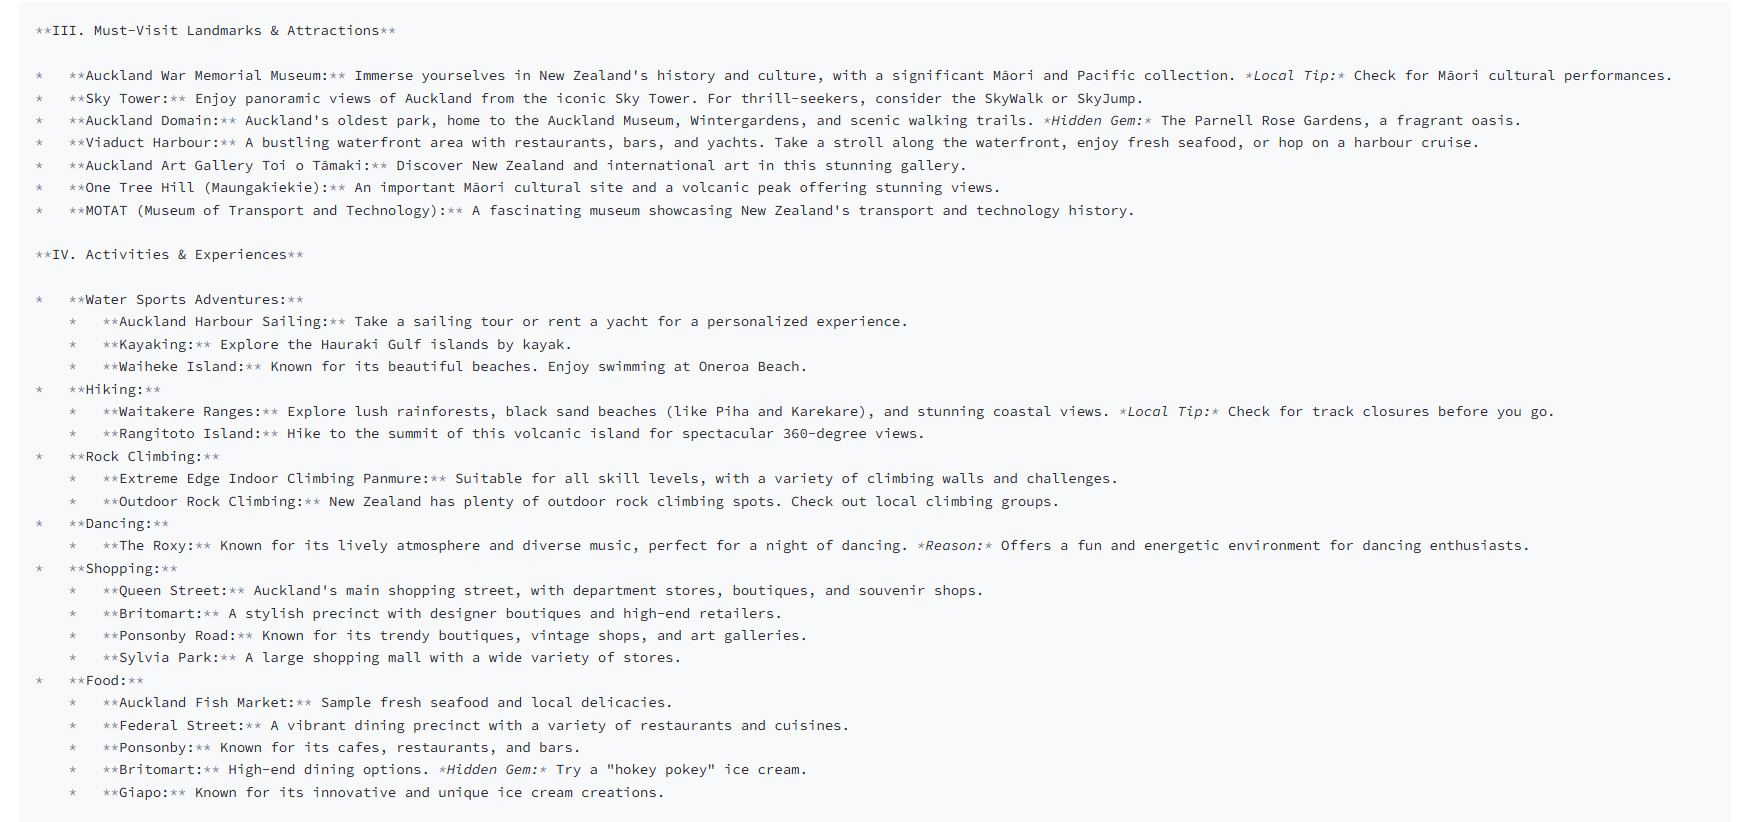 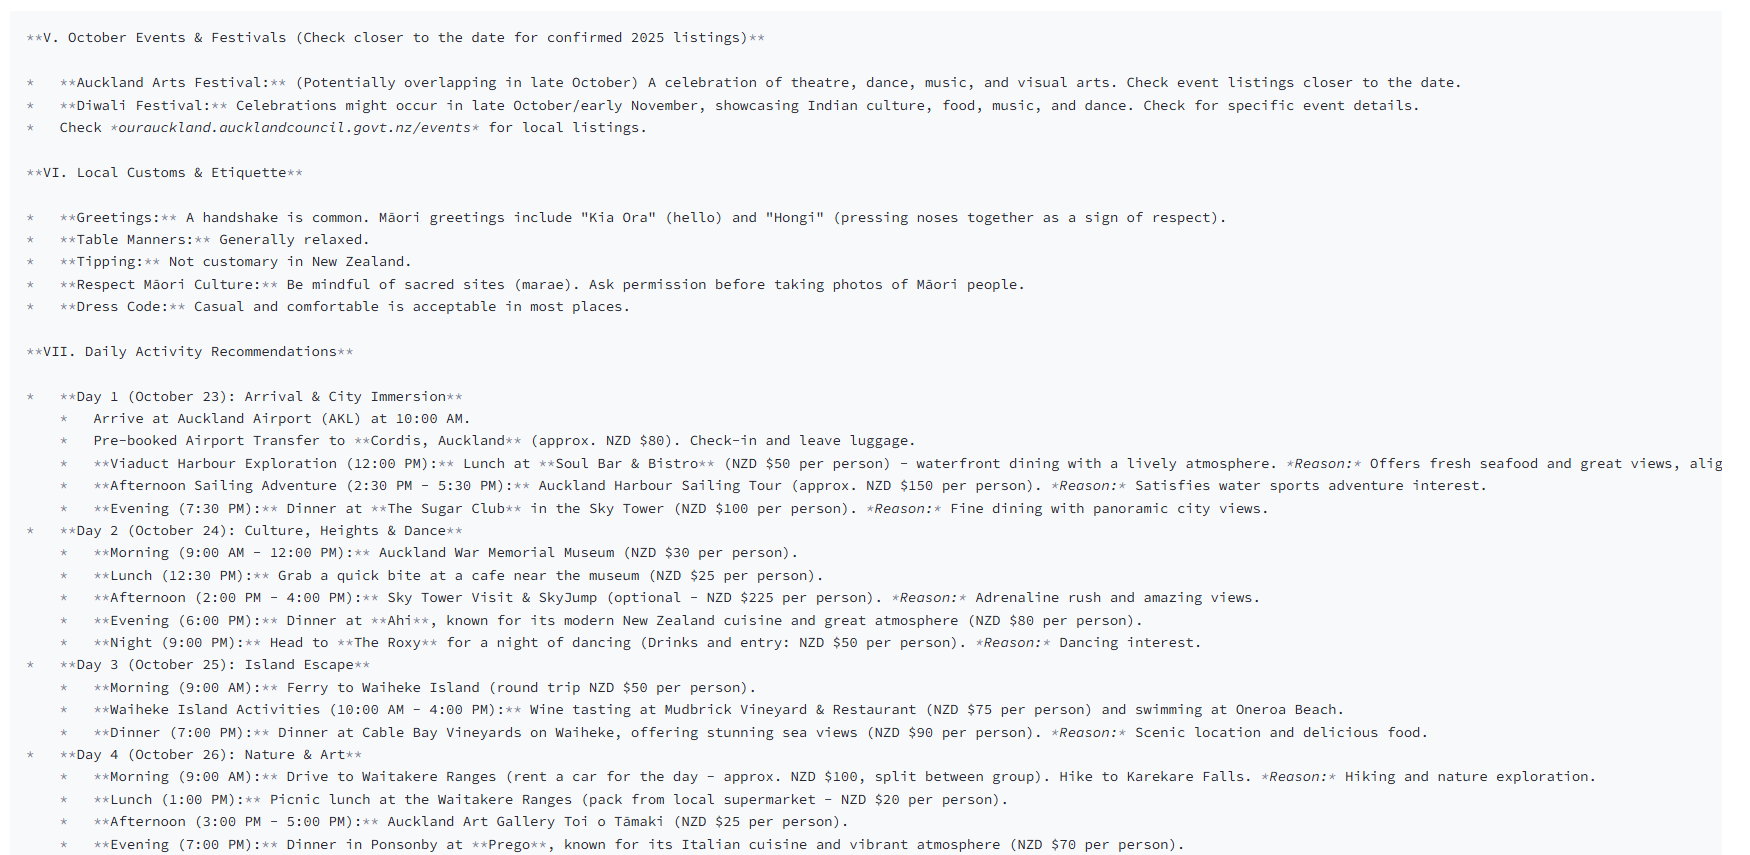 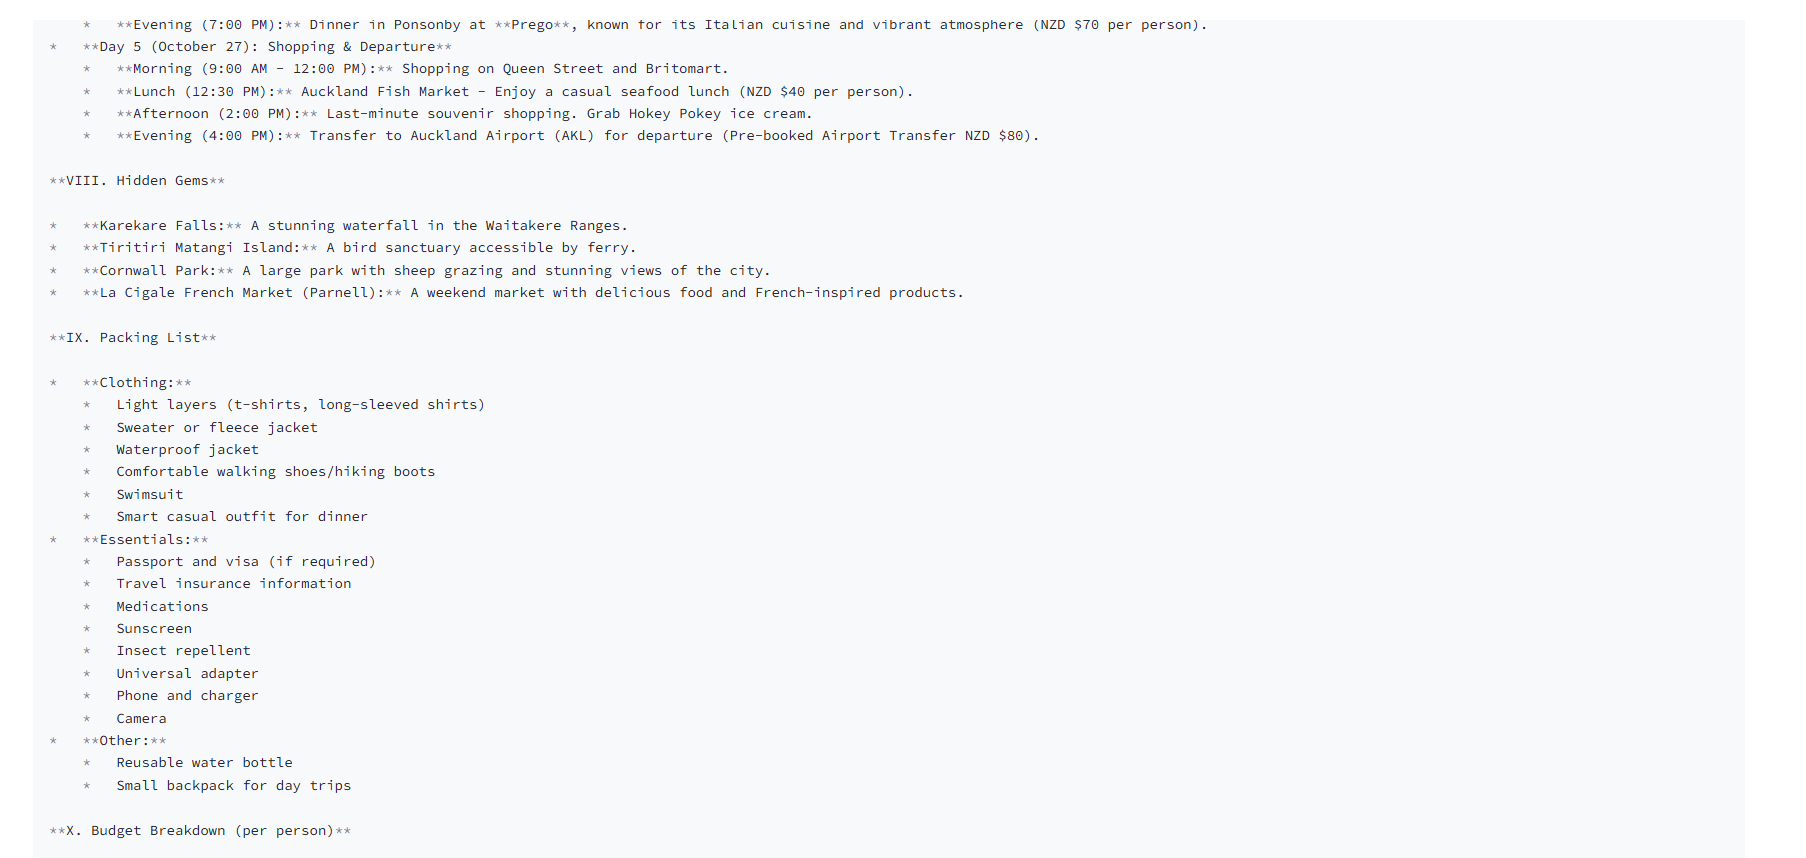
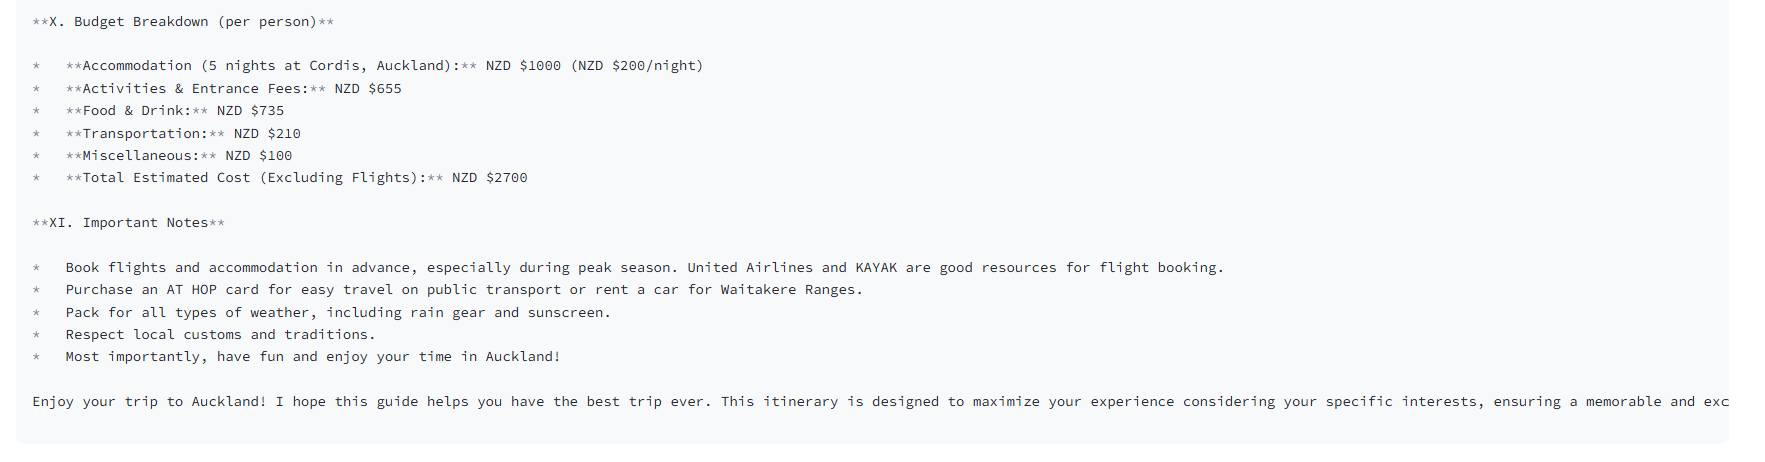

---

## Auckland: Your Ultimate Local's Guide (October 23-27, 2025) - THE BEST TRIP EVER!

Kia Ora! Welcome to Auckland, New Zealand – the "City of Sails"! This guide is crafted to provide an unforgettable experience for four adults from Bihar, Chhapra, passionate about swimming, dancing, hiking, shopping, food, water sports adventures, and rock climbing.

**I. Essential Information**

*   **Dates:** October 23-27, 2025
*   **Travelers:** Four adults
*   **Interests:** Swimming, dancing, hiking, shopping, food, water sports, rock climbing
*   **Currency:** New Zealand Dollar (NZD)
*   **Language:** English, Māori
*   **Weather in October:** Springtime in Auckland brings pleasant weather. Expect average temperatures between 12°C (52°F) and 18°C (64°F). There's a chance of rain throughout the period, so prepare for some showers. Expect about 6 hours of sunshine per day.
*   **Estimated Daily Cost:** NZD $170 per person (excluding flights), covering accommodation, food, activities, and transportation. Budget extra for premium experiences. (increased to account for specific recommendations)
*   **Transportation:**
    *   Auckland Airport (AKL) is well-connected. Consider pre-booking an airport transfer or taking the SkyBus.
    *   Within the city, use the AT HOP card for integrated public transport (buses, trains, ferries). Ride-sharing services (Uber, Ola) are also available. Renting a car provides flexibility for exploring beyond the city, especially for hiking locations.

**II. Accommodation Recommendation**

*   **Cordis, Auckland by Langham Hospitality Group:** Located in the city centre, this hotel features a stunning pool, excellent dining options, and easy access to major attractions. *Reason:* Caters to swimming interests, central location simplifies exploration.

**III. Must-Visit Landmarks & Attractions**

*   **Auckland War Memorial Museum:** Immerse yourselves in New Zealand's history and culture, with a significant Māori and Pacific collection. *Local Tip:* Check for Māori cultural performances.
*   **Sky Tower:** Enjoy panoramic views of Auckland from the iconic Sky Tower. For thrill-seekers, consider the SkyWalk or SkyJump.
*   **Auckland Domain:** Auckland's oldest park, home to the Auckland Museum, Wintergardens, and scenic walking trails. *Hidden Gem:* The Parnell Rose Gardens, a fragrant oasis.
*   **Viaduct Harbour:** A bustling waterfront area with restaurants, bars, and yachts. Take a stroll along the waterfront, enjoy fresh seafood, or hop on a harbour cruise.
*   **Auckland Art Gallery Toi o Tāmaki:** Discover New Zealand and international art in this stunning gallery.
*   **One Tree Hill (Maungakiekie):** An important Māori cultural site and a volcanic peak offering stunning views.
*   **MOTAT (Museum of Transport and Technology):** A fascinating museum showcasing New Zealand's transport and technology history.

**IV. Activities & Experiences**

*   **Water Sports Adventures:**
    *   **Auckland Harbour Sailing:** Take a sailing tour or rent a yacht for a personalized experience.
    *   **Kayaking:** Explore the Hauraki Gulf islands by kayak.
    *   **Waiheke Island:** Known for its beautiful beaches. Enjoy swimming at Oneroa Beach.
*   **Hiking:**
    *   **Waitakere Ranges:** Explore lush rainforests, black sand beaches (like Piha and Karekare), and stunning coastal views. *Local Tip:* Check for track closures before you go.
    *   **Rangitoto Island:** Hike to the summit of this volcanic island for spectacular 360-degree views.
*   **Rock Climbing:**
    *   **Extreme Edge Indoor Climbing Panmure:** Suitable for all skill levels, with a variety of climbing walls and challenges.
    *   **Outdoor Rock Climbing:** New Zealand has plenty of outdoor rock climbing spots. Check out local climbing groups.
*   **Dancing:**
    *   **The Roxy:** Known for its lively atmosphere and diverse music, perfect for a night of dancing. *Reason:* Offers a fun and energetic environment for dancing enthusiasts.
*   **Shopping:**
    *   **Queen Street:** Auckland's main shopping street, with department stores, boutiques, and souvenir shops.
    *   **Britomart:** A stylish precinct with designer boutiques and high-end retailers.
    *   **Ponsonby Road:** Known for its trendy boutiques, vintage shops, and art galleries.
    *   **Sylvia Park:** A large shopping mall with a wide variety of stores.
*   **Food:**
    *   **Auckland Fish Market:** Sample fresh seafood and local delicacies.
    *   **Federal Street:** A vibrant dining precinct with a variety of restaurants and cuisines.
    *   **Ponsonby:** Known for its cafes, restaurants, and bars.
    *   **Britomart:** High-end dining options. *Hidden Gem:* Try a "hokey pokey" ice cream.
    *   **Giapo:** Known for its innovative and unique ice cream creations.

**V. October Events & Festivals (Check closer to the date for confirmed 2025 listings)**

*   **Auckland Arts Festival:** (Potentially overlapping in late October) A celebration of theatre, dance, music, and visual arts. Check event listings closer to the date.
*   **Diwali Festival:** Celebrations might occur in late October/early November, showcasing Indian culture, food, music, and dance. Check for specific event details.
*   Check *ourauckland.aucklandcouncil.govt.nz/events* for local listings.

**VI. Local Customs & Etiquette**

*   **Greetings:** A handshake is common. Māori greetings include "Kia Ora" (hello) and "Hongi" (pressing noses together as a sign of respect).
*   **Table Manners:** Generally relaxed.
*   **Tipping:** Not customary in New Zealand.
*   **Respect Māori Culture:** Be mindful of sacred sites (marae). Ask permission before taking photos of Māori people.
*   **Dress Code:** Casual and comfortable is acceptable in most places.

**VII. Daily Activity Recommendations**

*   **Day 1 (October 23): Arrival & City Immersion**
    *   Arrive at Auckland Airport (AKL) at 10:00 AM.
    *   Pre-booked Airport Transfer to **Cordis, Auckland** (approx. NZD $80). Check-in and leave luggage.
    *   **Viaduct Harbour Exploration (12:00 PM):** Lunch at **Soul Bar & Bistro** (NZD $50 per person) - waterfront dining with a lively atmosphere. *Reason:* Offers fresh seafood and great views, aligning with interests.
    *   **Afternoon Sailing Adventure (2:30 PM - 5:30 PM):** Auckland Harbour Sailing Tour (approx. NZD $150 per person). *Reason:* Satisfies water sports adventure interest.
    *   **Evening (7:30 PM):** Dinner at **The Sugar Club** in the Sky Tower (NZD $100 per person). *Reason:* Fine dining with panoramic city views.
*   **Day 2 (October 24): Culture, Heights & Dance**
    *   **Morning (9:00 AM - 12:00 PM):** Auckland War Memorial Museum (NZD $30 per person).
    *   **Lunch (12:30 PM):** Grab a quick bite at a cafe near the museum (NZD $25 per person).
    *   **Afternoon (2:00 PM - 4:00 PM):** Sky Tower Visit & SkyJump (optional - NZD $225 per person). *Reason:* Adrenaline rush and amazing views.
    *   **Evening (6:00 PM):** Dinner at **Ahi**, known for its modern New Zealand cuisine and great atmosphere (NZD $80 per person).
    *   **Night (9:00 PM):** Head to **The Roxy** for a night of dancing (Drinks and entry: NZD $50 per person). *Reason:* Dancing interest.
*   **Day 3 (October 25): Island Escape**
    *   **Morning (9:00 AM):** Ferry to Waiheke Island (round trip NZD $50 per person).
    *   **Waiheke Island Activities (10:00 AM - 4:00 PM):** Wine tasting at Mudbrick Vineyard & Restaurant (NZD $75 per person) and swimming at Oneroa Beach.
    *   **Dinner (7:00 PM):** Dinner at Cable Bay Vineyards on Waiheke, offering stunning sea views (NZD $90 per person). *Reason:* Scenic location and delicious food.
*   **Day 4 (October 26): Nature & Art**
    *   **Morning (9:00 AM):** Drive to Waitakere Ranges (rent a car for the day - approx. NZD $100, split between group). Hike to Karekare Falls. *Reason:* Hiking and nature exploration.
    *   **Lunch (1:00 PM):** Picnic lunch at the Waitakere Ranges (pack from local supermarket - NZD $20 per person).
    *   **Afternoon (3:00 PM - 5:00 PM):** Auckland Art Gallery Toi o Tāmaki (NZD $25 per person).
    *   **Evening (7:00 PM):** Dinner in Ponsonby at **Prego**, known for its Italian cuisine and vibrant atmosphere (NZD $70 per person).
*   **Day 5 (October 27): Shopping & Departure**
    *   **Morning (9:00 AM - 12:00 PM):** Shopping on Queen Street and Britomart.
    *   **Lunch (12:30 PM):** Auckland Fish Market - Enjoy a casual seafood lunch (NZD $40 per person).
    *   **Afternoon (2:00 PM):** Last-minute souvenir shopping. Grab Hokey Pokey ice cream.
    *   **Evening (4:00 PM):** Transfer to Auckland Airport (AKL) for departure (Pre-booked Airport Transfer NZD $80).

**VIII. Hidden Gems**

*   **Karekare Falls:** A stunning waterfall in the Waitakere Ranges.
*   **Tiritiri Matangi Island:** A bird sanctuary accessible by ferry.
*   **Cornwall Park:** A large park with sheep grazing and stunning views of the city.
*   **La Cigale French Market (Parnell):** A weekend market with delicious food and French-inspired products.

**IX. Packing List**

*   **Clothing:**
    *   Light layers (t-shirts, long-sleeved shirts)
    *   Sweater or fleece jacket
    *   Waterproof jacket
    *   Comfortable walking shoes/hiking boots
    *   Swimsuit
    *   Smart casual outfit for dinner
*   **Essentials:**
    *   Passport and visa (if required)
    *   Travel insurance information
    *   Medications
    *   Sunscreen
    *   Insect repellent
    *   Universal adapter
    *   Phone and charger
    *   Camera
*   **Other:**
    *   Reusable water bottle
    *   Small backpack for day trips

**X. Budget Breakdown (per person)**

*   **Accommodation (5 nights at Cordis, Auckland):** NZD $1000 (NZD $200/night)
*   **Activities & Entrance Fees:** NZD $655
*   **Food & Drink:** NZD $735
*   **Transportation:** NZD $210
*   **Miscellaneous:** NZD $100
*   **Total Estimated Cost (Excluding Flights):** NZD $2700

**XI. Important Notes**

*   Book flights and accommodation in advance, especially during peak season. United Airlines and KAYAK are good resources for flight booking.
*   Purchase an AT HOP card for easy travel on public transport or rent a car for Waitakere Ranges.
*   Pack for all types of weather, including rain gear and sunscreen.
*   Respect local customs and traditions.
*   Most importantly, have fun and enjoy your time in Auckland!

Enjoy your trip to Auckland! I hope this guide helps you have the best trip ever. This itinerary is designed to maximize your experience considering your specific interests, ensuring a memorable and exciting trip. The restaurant and activity choices are made to reflect both adventure and relaxation, catering to all preferences within the group.

---

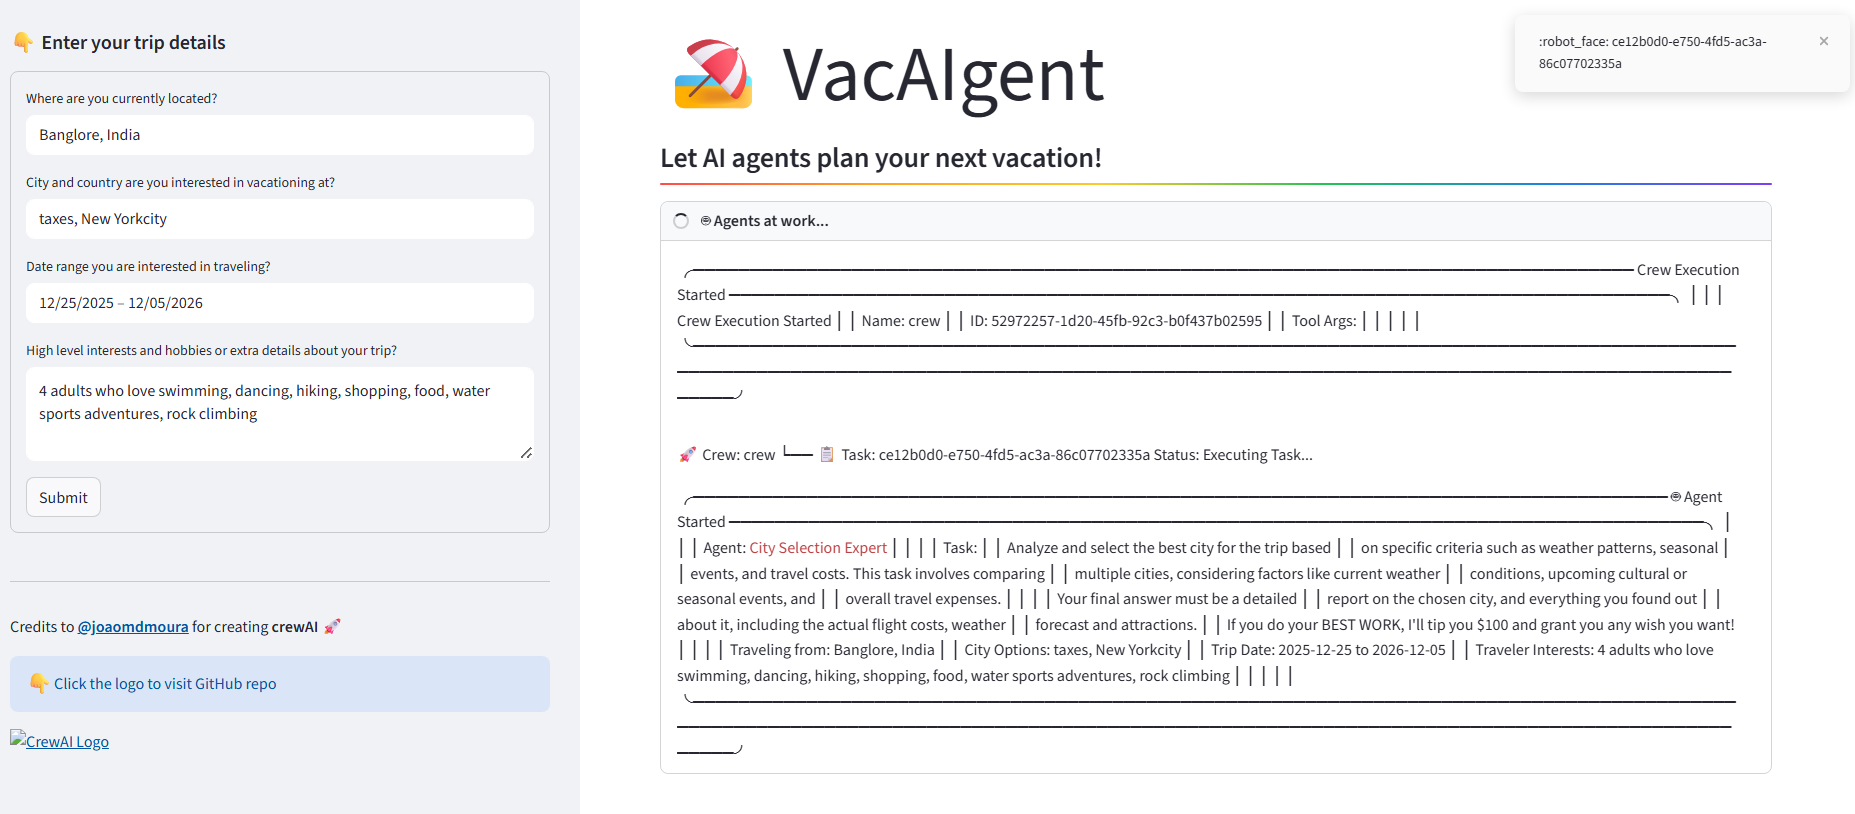 <br> 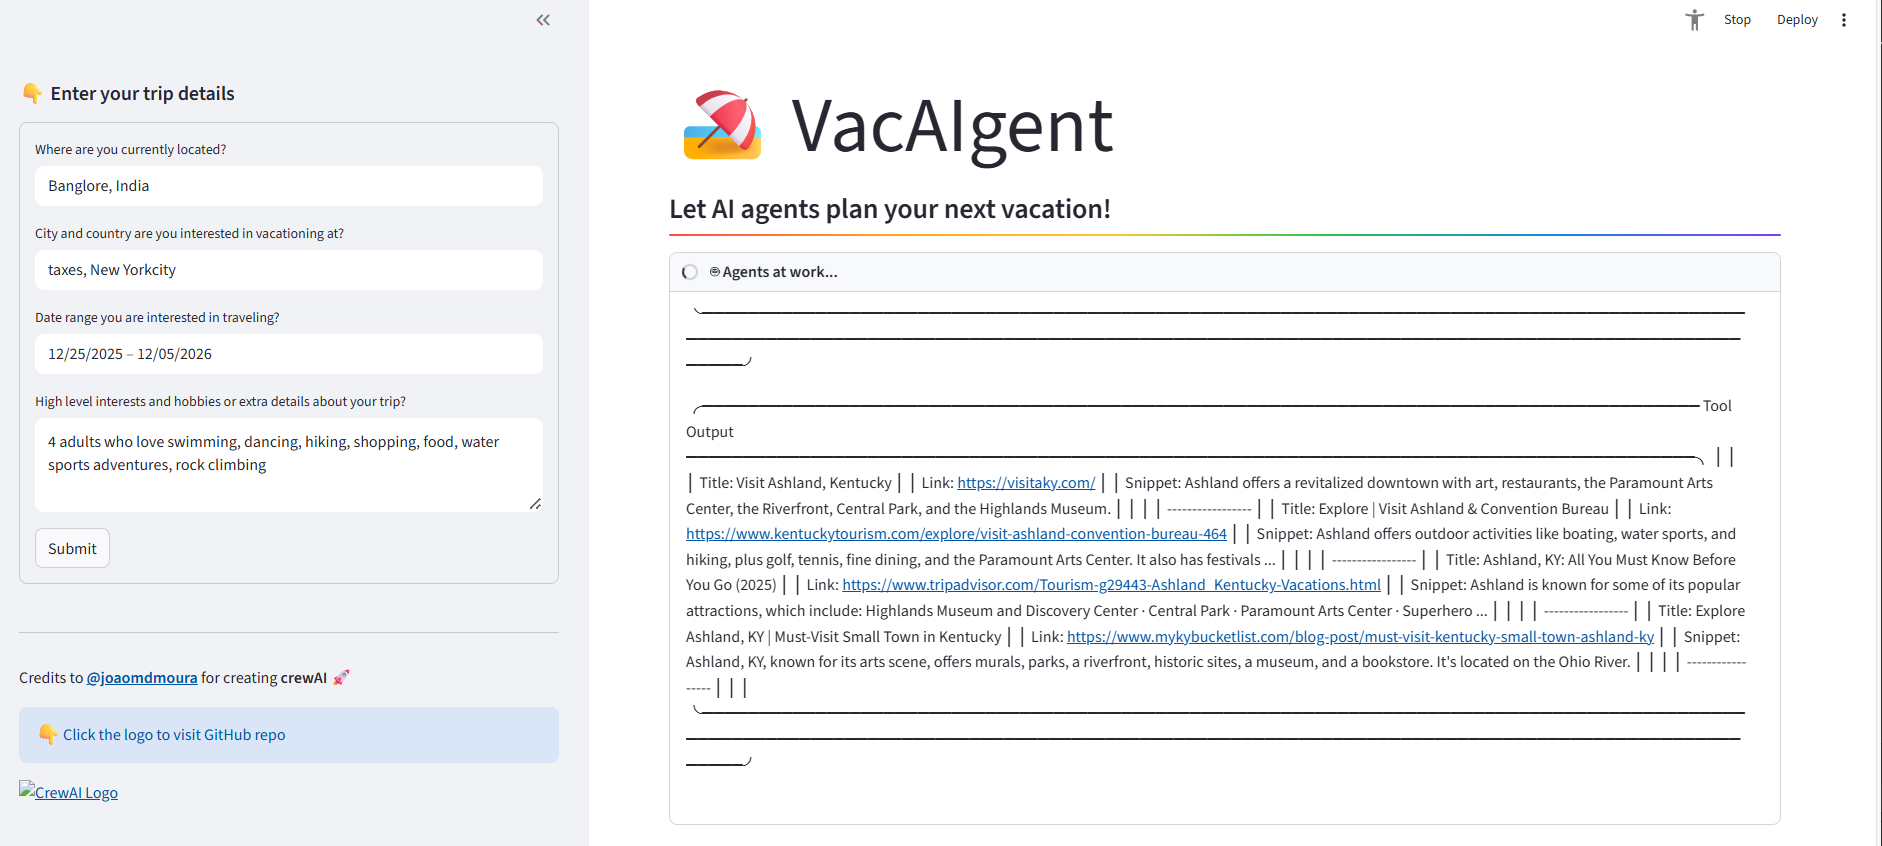 <br> 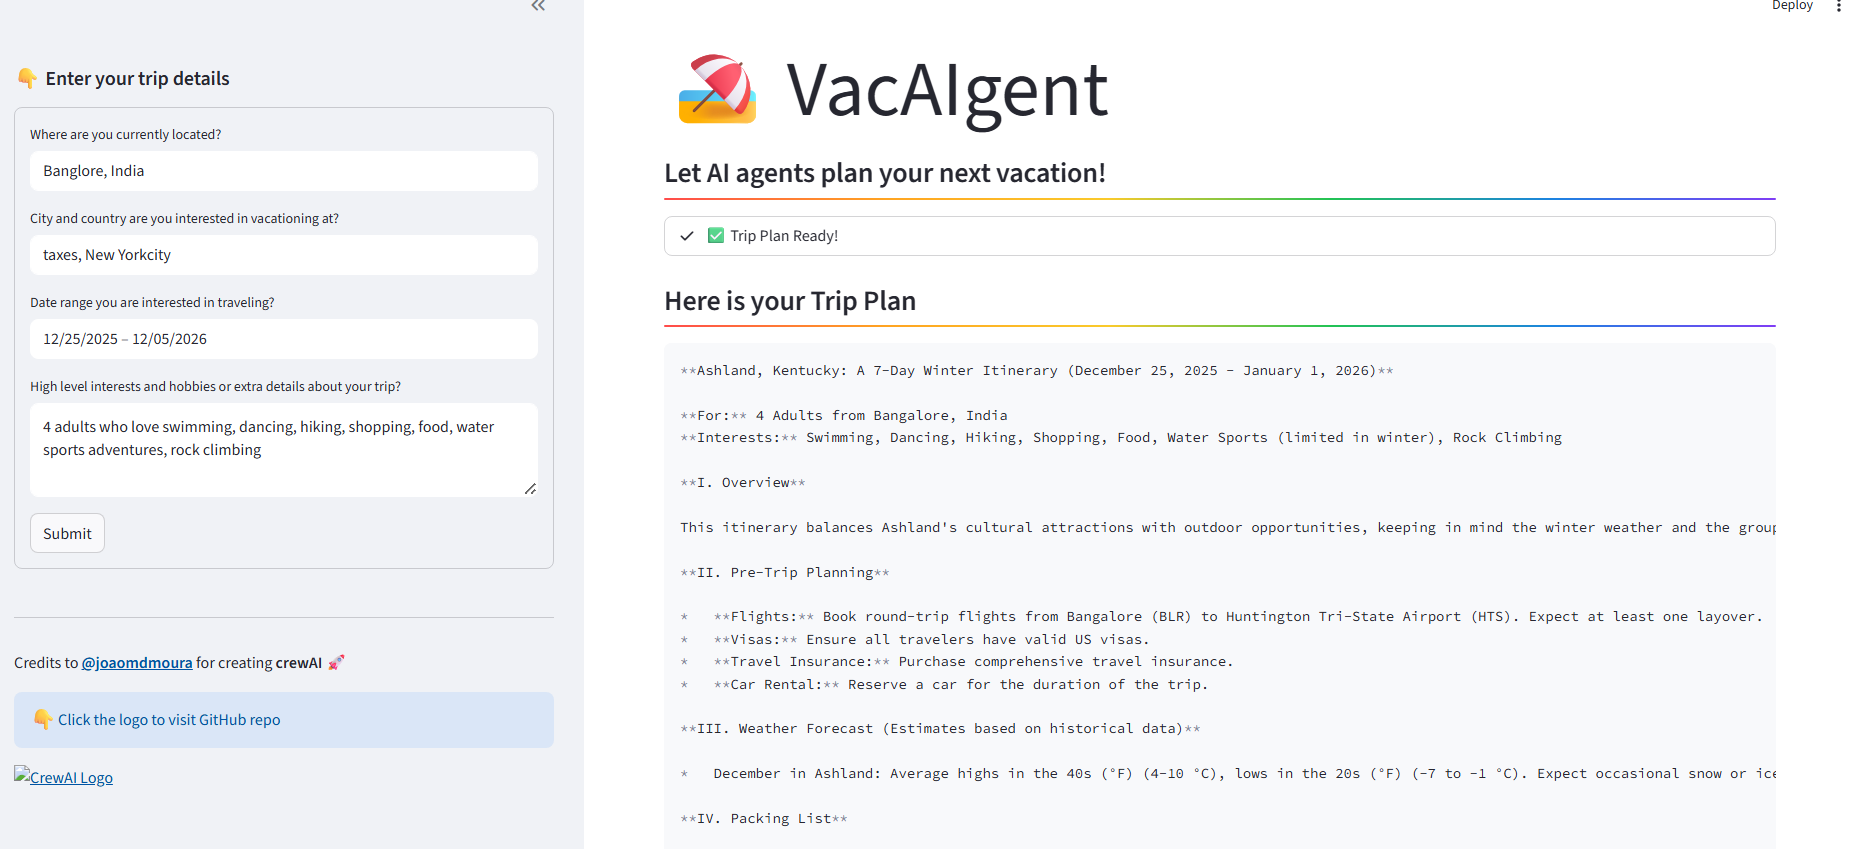 <br><br>
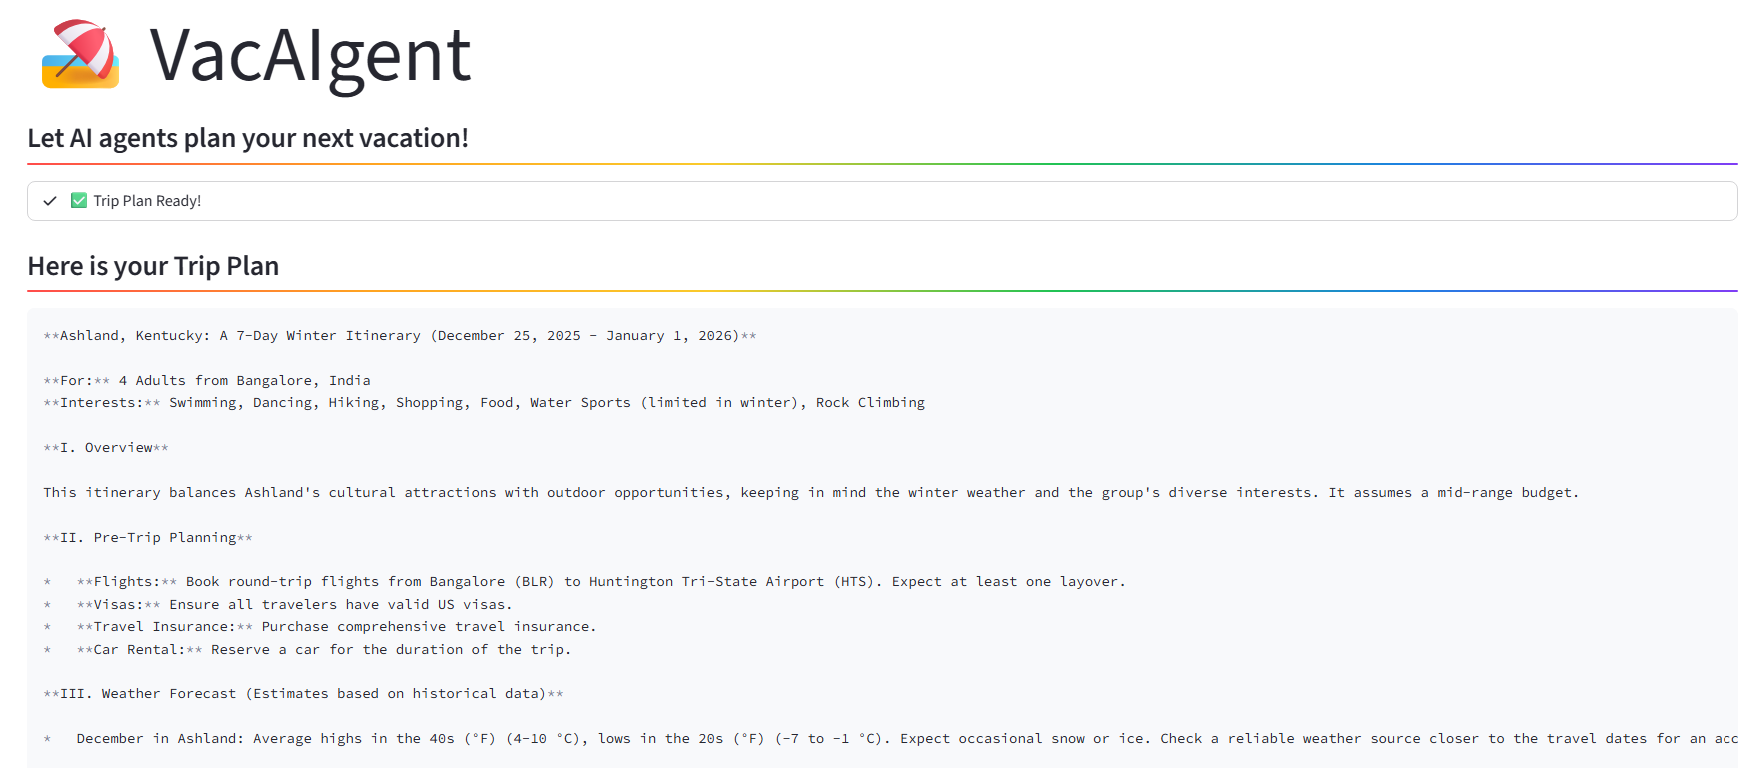 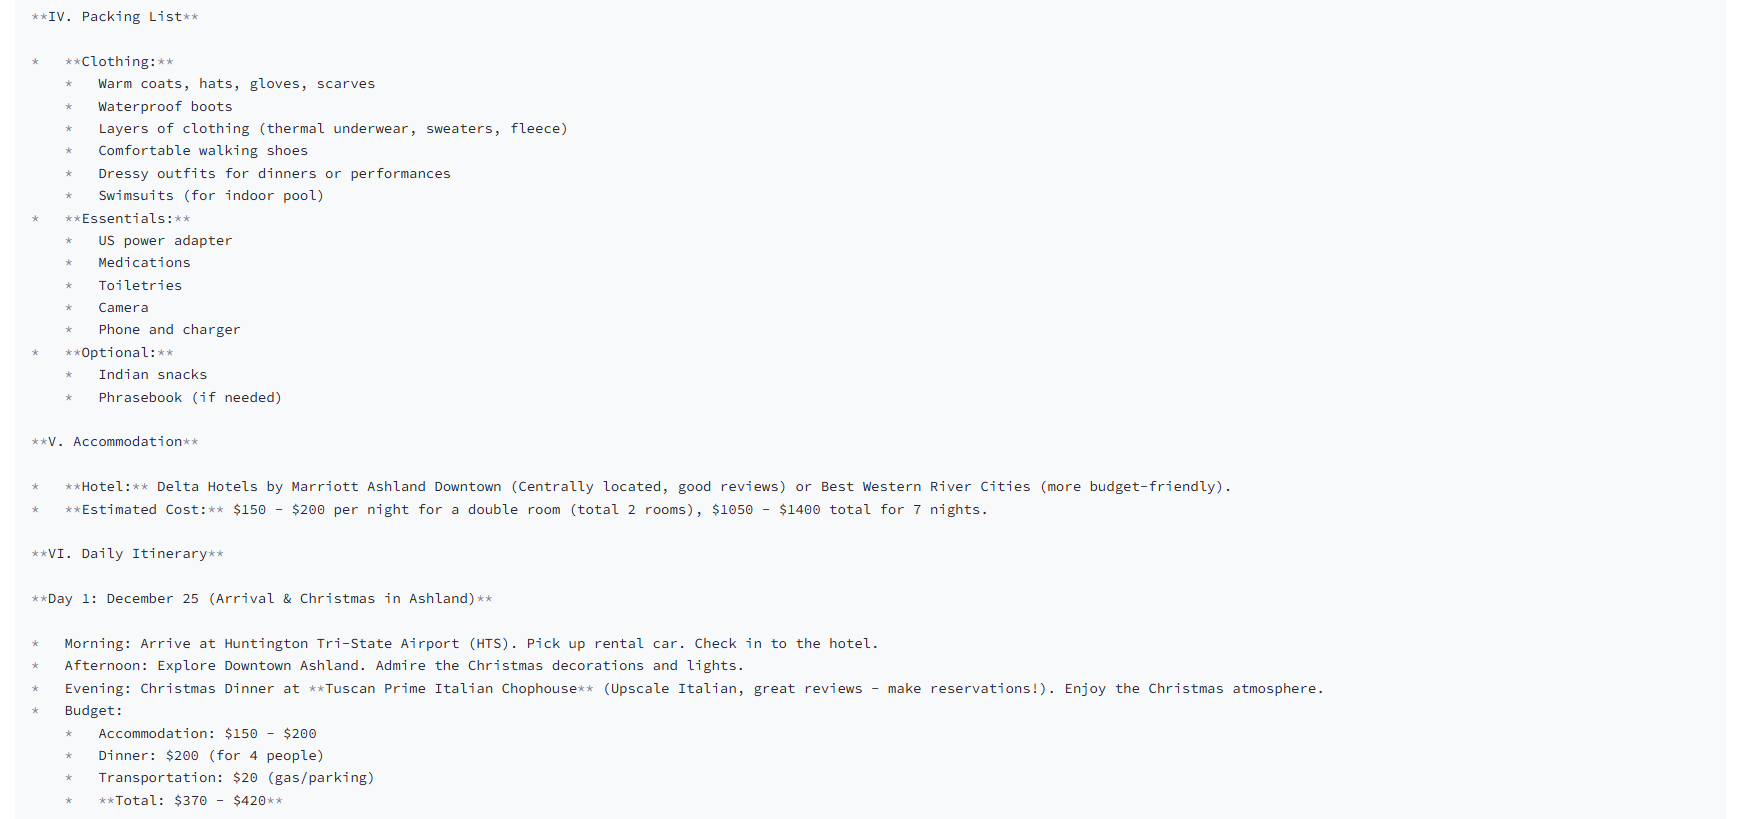 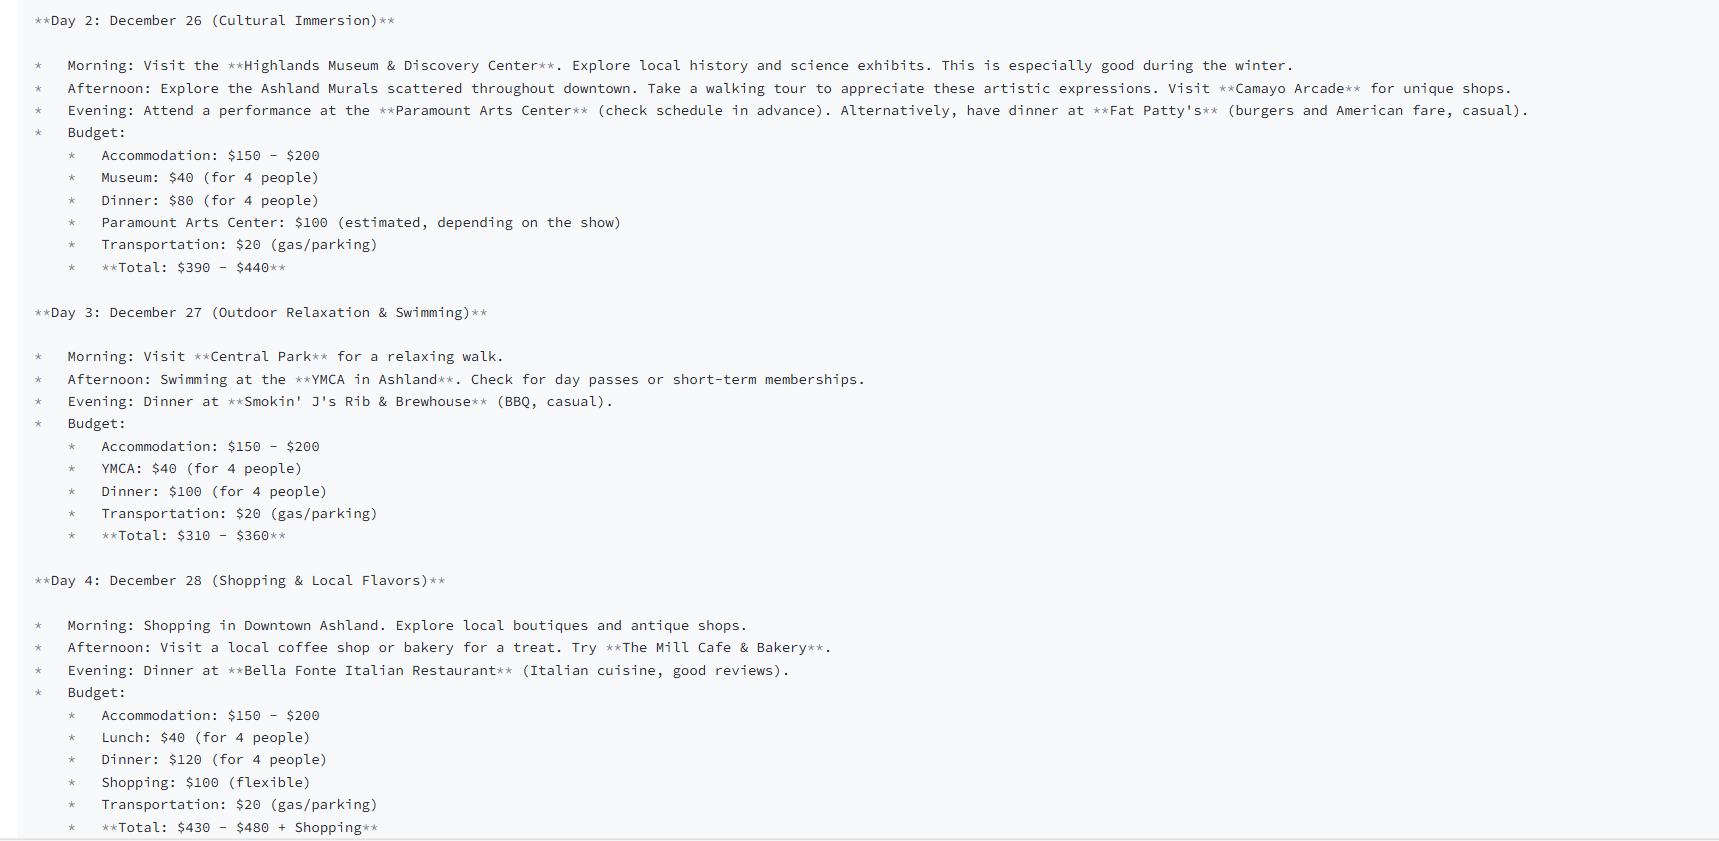 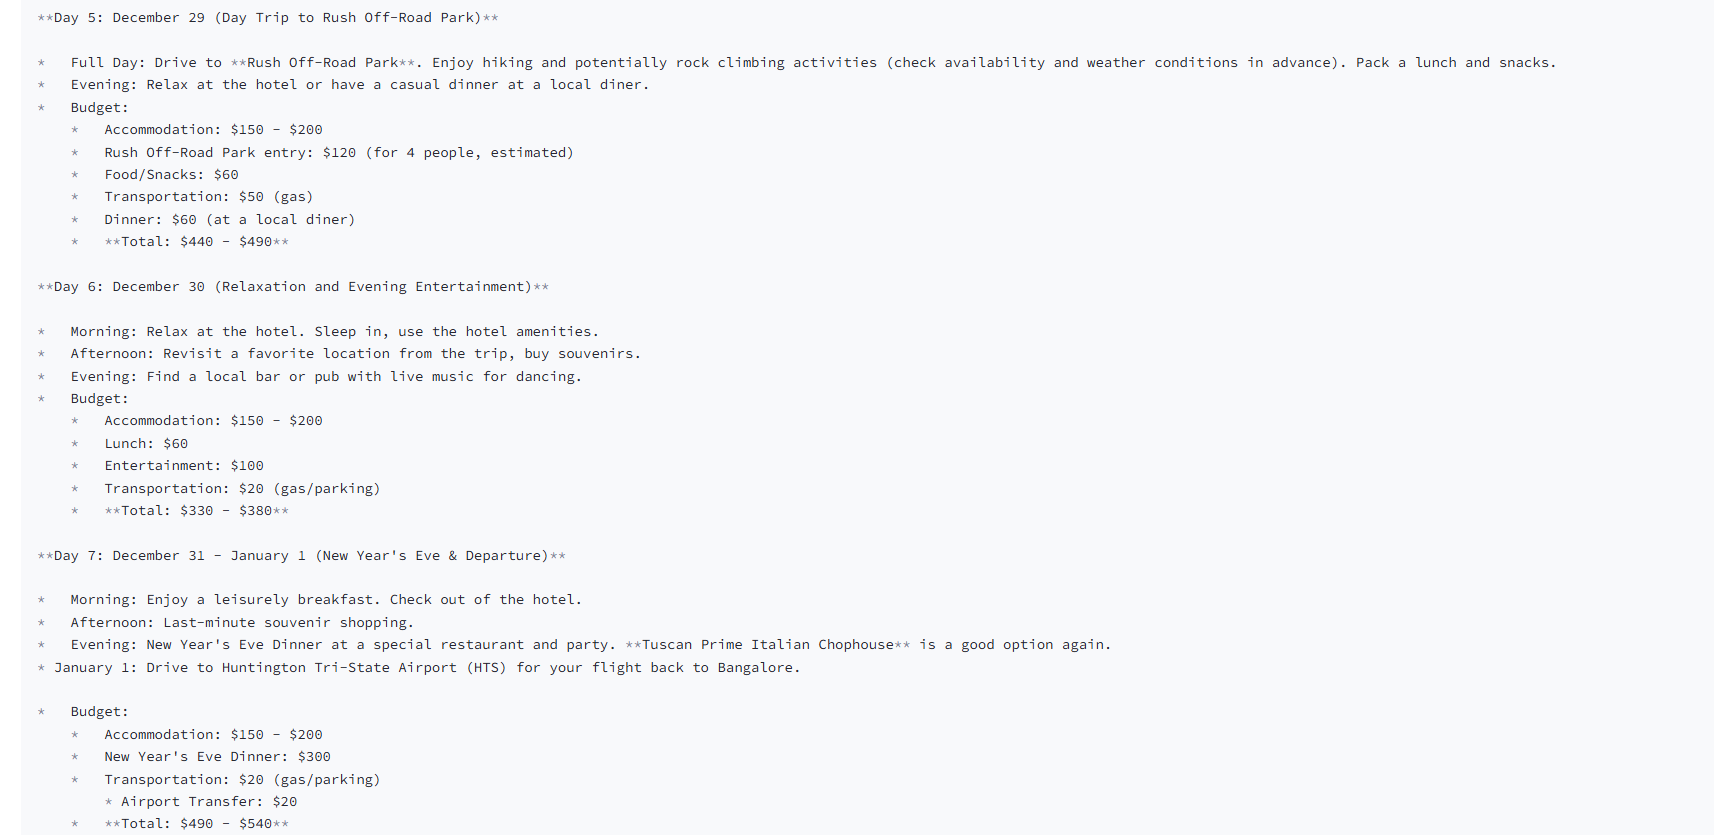
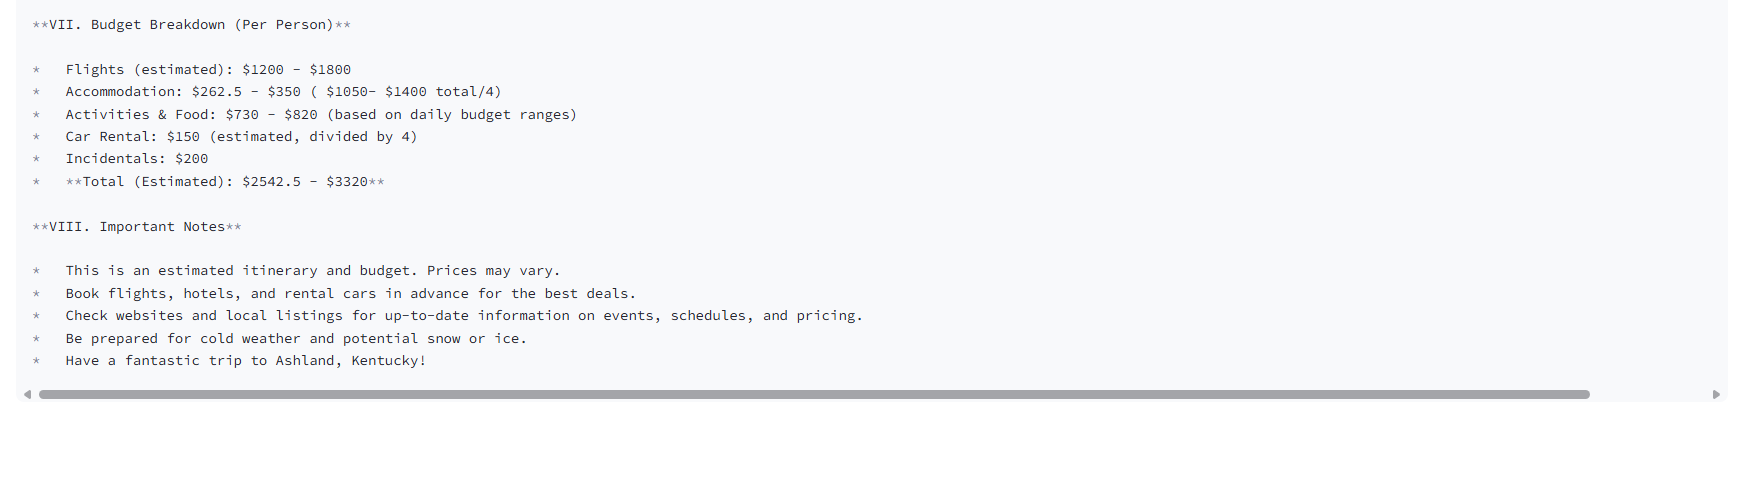

---

**Ashland, Kentucky: A 7-Day Winter Itinerary (December 25, 2025 - January 1, 2026)**

**For:** 4 Adults from Bangalore, India
**Interests:** Swimming, Dancing, Hiking, Shopping, Food, Water Sports (limited in winter), Rock Climbing

**I. Overview**

This itinerary balances Ashland's cultural attractions with outdoor opportunities, keeping in mind the winter weather and the group's diverse interests. It assumes a mid-range budget.

**II. Pre-Trip Planning**

*   **Flights:** Book round-trip flights from Bangalore (BLR) to Huntington Tri-State Airport (HTS). Expect at least one layover.
*   **Visas:** Ensure all travelers have valid US visas.
*   **Travel Insurance:** Purchase comprehensive travel insurance.
*   **Car Rental:** Reserve a car for the duration of the trip.

**III. Weather Forecast (Estimates based on historical data)**

*   December in Ashland: Average highs in the 40s (°F) (4-10 °C), lows in the 20s (°F) (-7 to -1 °C). Expect occasional snow or ice. Check a reliable weather source closer to the travel dates for an accurate forecast.

**IV. Packing List**

*   **Clothing:**
    *   Warm coats, hats, gloves, scarves
    *   Waterproof boots
    *   Layers of clothing (thermal underwear, sweaters, fleece)
    *   Comfortable walking shoes
    *   Dressy outfits for dinners or performances
    *   Swimsuits (for indoor pool)
*   **Essentials:**
    *   US power adapter
    *   Medications
    *   Toiletries
    *   Camera
    *   Phone and charger
*   **Optional:**
    *   Indian snacks
    *   Phrasebook (if needed)

**V. Accommodation**

*   **Hotel:** Delta Hotels by Marriott Ashland Downtown (Centrally located, good reviews) or Best Western River Cities (more budget-friendly).
*   **Estimated Cost:** $150 - $200 per night for a double room (total 2 rooms), $1050 - $1400 total for 7 nights.

**VI. Daily Itinerary**

**Day 1: December 25 (Arrival & Christmas in Ashland)**

*   Morning: Arrive at Huntington Tri-State Airport (HTS). Pick up rental car. Check in to the hotel.
*   Afternoon: Explore Downtown Ashland. Admire the Christmas decorations and lights.
*   Evening: Christmas Dinner at **Tuscan Prime Italian Chophouse** (Upscale Italian, great reviews - make reservations!). Enjoy the Christmas atmosphere.
*   Budget:
    *   Accommodation: $150 - $200
    *   Dinner: $200 (for 4 people)
    *   Transportation: $20 (gas/parking)
    *   **Total: $370 - $420**

**Day 2: December 26 (Cultural Immersion)**

*   Morning: Visit the **Highlands Museum & Discovery Center**. Explore local history and science exhibits. This is especially good during the winter.
*   Afternoon: Explore the Ashland Murals scattered throughout downtown. Take a walking tour to appreciate these artistic expressions. Visit **Camayo Arcade** for unique shops.
*   Evening: Attend a performance at the **Paramount Arts Center** (check schedule in advance). Alternatively, have dinner at **Fat Patty's** (burgers and American fare, casual).
*   Budget:
    *   Accommodation: $150 - $200
    *   Museum: $40 (for 4 people)
    *   Dinner: $80 (for 4 people)
    *   Paramount Arts Center: $100 (estimated, depending on the show)
    *   Transportation: $20 (gas/parking)
    *   **Total: $390 - $440**

**Day 3: December 27 (Outdoor Relaxation & Swimming)**

*   Morning: Visit **Central Park** for a relaxing walk.
*   Afternoon: Swimming at the **YMCA in Ashland**. Check for day passes or short-term memberships.
*   Evening: Dinner at **Smokin' J's Rib & Brewhouse** (BBQ, casual).
*   Budget:
    *   Accommodation: $150 - $200
    *   YMCA: $40 (for 4 people)
    *   Dinner: $100 (for 4 people)
    *   Transportation: $20 (gas/parking)
    *   **Total: $310 - $360**

**Day 4: December 28 (Shopping & Local Flavors)**

*   Morning: Shopping in Downtown Ashland. Explore local boutiques and antique shops.
*   Afternoon: Visit a local coffee shop or bakery for a treat. Try **The Mill Cafe & Bakery**.
*   Evening: Dinner at **Bella Fonte Italian Restaurant** (Italian cuisine, good reviews).
*   Budget:
    *   Accommodation: $150 - $200
    *   Lunch: $40 (for 4 people)
    *   Dinner: $120 (for 4 people)
    *   Shopping: $100 (flexible)
    *   Transportation: $20 (gas/parking)
    *   **Total: $430 - $480 + Shopping**

**Day 5: December 29 (Day Trip to Rush Off-Road Park)**

*   Full Day: Drive to **Rush Off-Road Park**. Enjoy hiking and potentially rock climbing activities (check availability and weather conditions in advance). Pack a lunch and snacks.
*   Evening: Relax at the hotel or have a casual dinner at a local diner.
*   Budget:
    *   Accommodation: $150 - $200
    *   Rush Off-Road Park entry: $120 (for 4 people, estimated)
    *   Food/Snacks: $60
    *   Transportation: $50 (gas)
    *   Dinner: $60 (at a local diner)
    *   **Total: $440 - $490**

**Day 6: December 30 (Relaxation and Evening Entertainment)**

*   Morning: Relax at the hotel. Sleep in, use the hotel amenities.
*   Afternoon: Revisit a favorite location from the trip, buy souvenirs.
*   Evening: Find a local bar or pub with live music for dancing.
*   Budget:
    *   Accommodation: $150 - $200
    *   Lunch: $60
    *   Entertainment: $100
    *   Transportation: $20 (gas/parking)
    *   **Total: $330 - $380**

**Day 7: December 31 - January 1 (New Year's Eve & Departure)**

*   Morning: Enjoy a leisurely breakfast. Check out of the hotel.
*   Afternoon: Last-minute souvenir shopping.
*   Evening: New Year's Eve Dinner at a special restaurant and party. **Tuscan Prime Italian Chophouse** is a good option again.
* January 1: Drive to Huntington Tri-State Airport (HTS) for your flight back to Bangalore.

*   Budget:
    *   Accommodation: $150 - $200
    *   New Year's Eve Dinner: $300
    *   Transportation: $20 (gas/parking)
        * Airport Transfer: $20
    *   **Total: $490 - $540**

**VII. Budget Breakdown (Per Person)**

*   Flights (estimated): $1200 - $1800
*   Accommodation: $262.5 - $350 ( $1050- $1400 total/4)
*   Activities & Food: $730 - $820 (based on daily budget ranges)
*   Car Rental: $150 (estimated, divided by 4)
*   Incidentals: $200
*   **Total (Estimated): $2542.5 - $3320**

**VIII. Important Notes**

*   This is an estimated itinerary and budget. Prices may vary.
*   Book flights, hotels, and rental cars in advance for the best deals.
*   Check websites and local listings for up-to-date information on events, schedules, and pricing.
*   Be prepared for cold weather and potential snow or ice.
*   Have a fantastic trip to Ashland, Kentucky!

---